In [ ]:
import pandas as pd
import numpy as np
import sklearn.preprocessing as sp

d = pd.read_csv("DATA_CW5 (S).csv", encoding="latin-1")
numeric = d.select_dtypes(include=['number']).mean()
d.fillna(numeric, inplace = True)
label = d['Satisfied'].to_numpy()
y = np.zeros(label.shape)
counter = 0
for value in label:
    if (value == 'Y'):
        y[counter] = 1
    elif (value == 'N'):
        y[counter] = 0
    else:
        raise Exception("Value other than Yes and No")
    counter = counter + 1

features = d.drop(columns=['Ref', 'id', 'Satisfied'])
features_d = pd.get_dummies(features, drop_first = True)
x = features_d.to_numpy()

In [4]:
x_scaled= sp.StandardScaler().fit_transform(x)

index = np.arange(x_scaled.shape[0])
np.random.seed(10)
np.random.shuffle(index)
training_bound = (int)(0.8*len(x_scaled))
validation_bound = (int)(0.9*len(x_scaled))

train = index[:training_bound]
val = index [training_bound : validation_bound]
test = index[validation_bound:]

x_train = x_scaled[train]
y_train = y[train]
x_val = x_scaled[val]
y_val = y[val]
x_test = x_scaled[test]
y_test = y[test]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 27 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Ref                                103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Satisfied                          103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Age Band                           103904 non-null  object 
 6   Type of Travel                     103904 non-null  object 
 7   Class                              103904 non-null  object 
 8   Flight Distance                    103904 non-null  int64  
 9   Destination                        103904 non-null  object 
 10  Continent                          103904 non-null  object 
 11  Inflight wifi service              1039

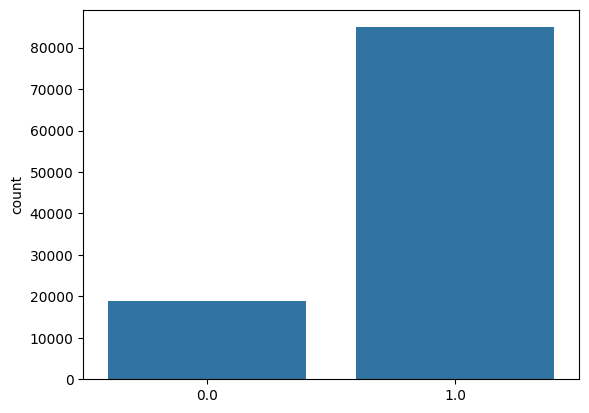

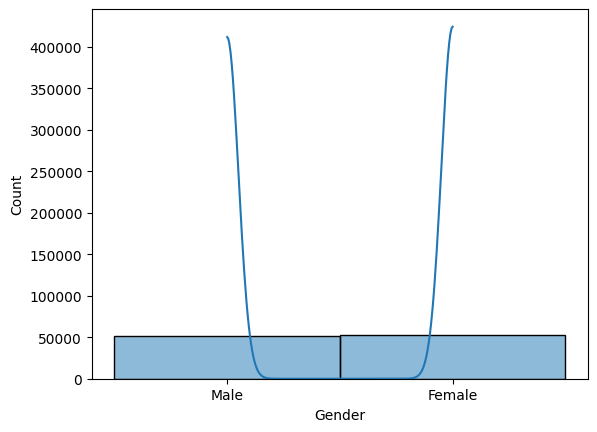

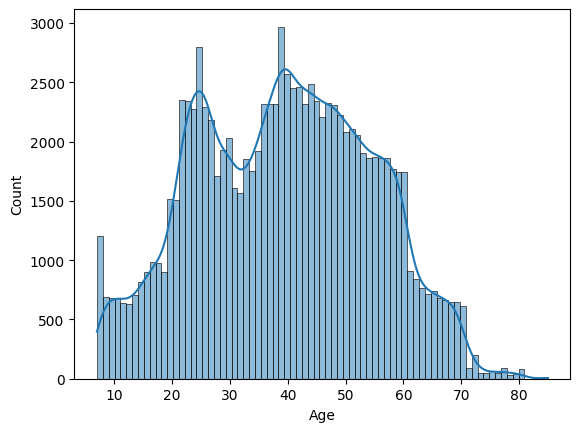

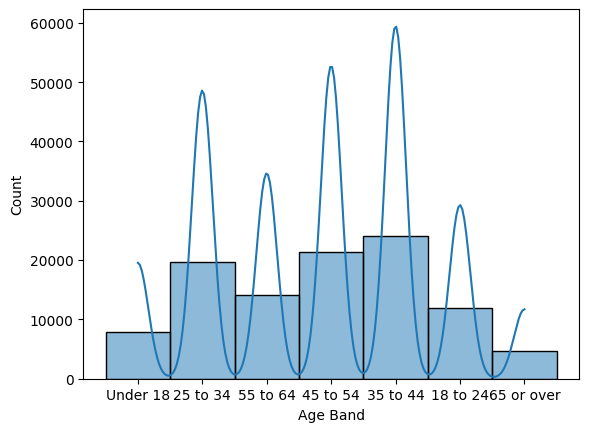

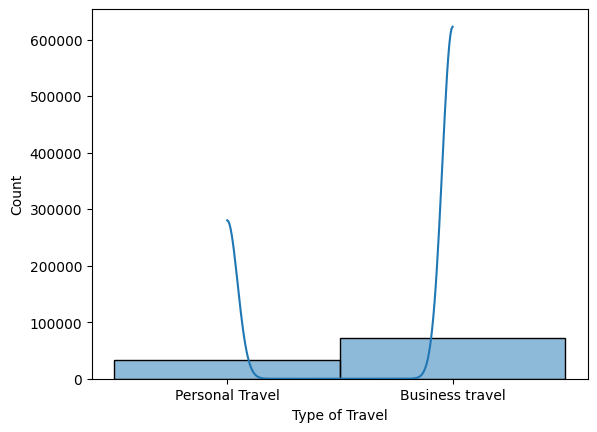

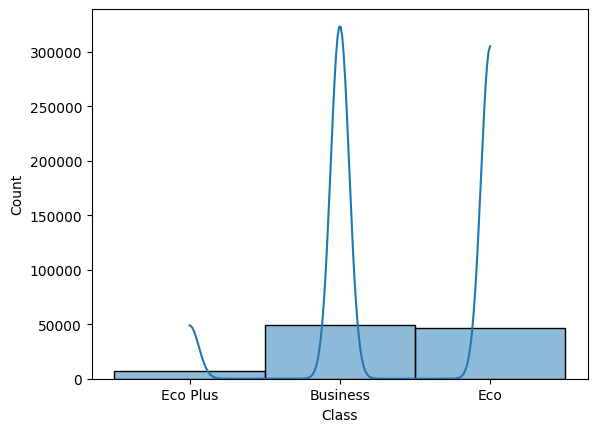

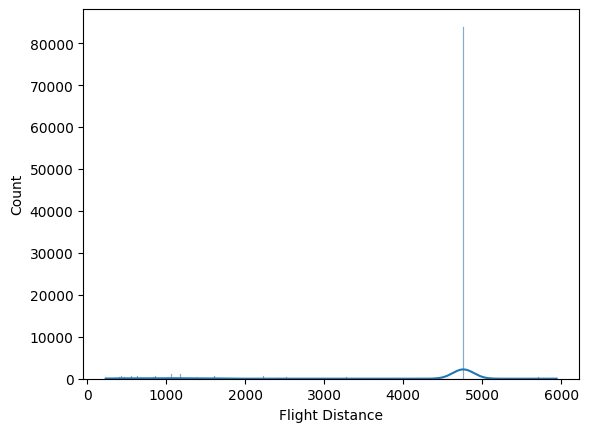

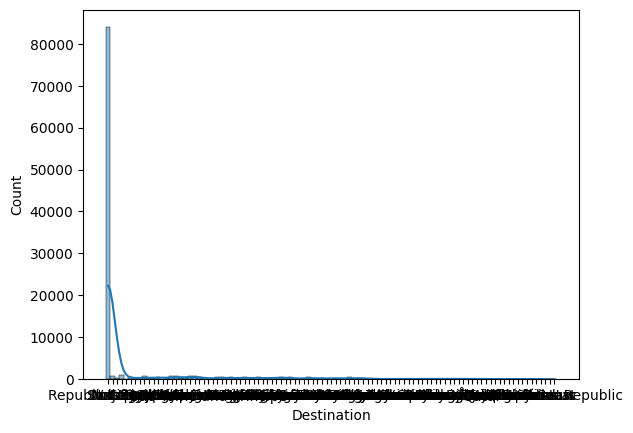

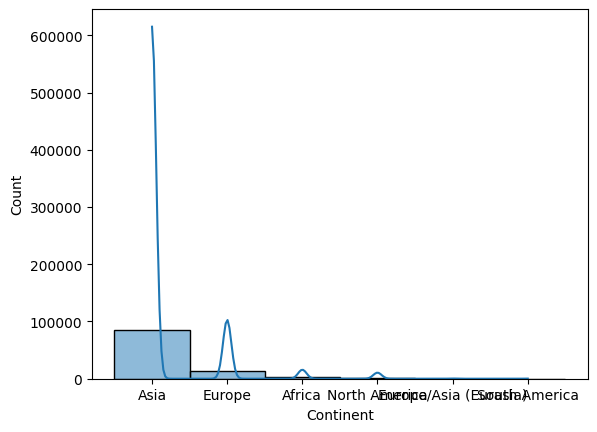

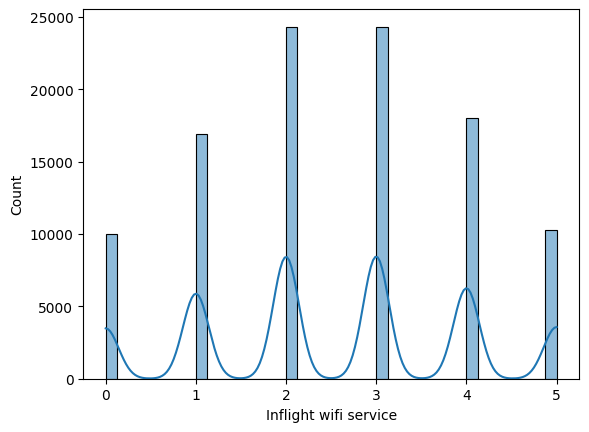

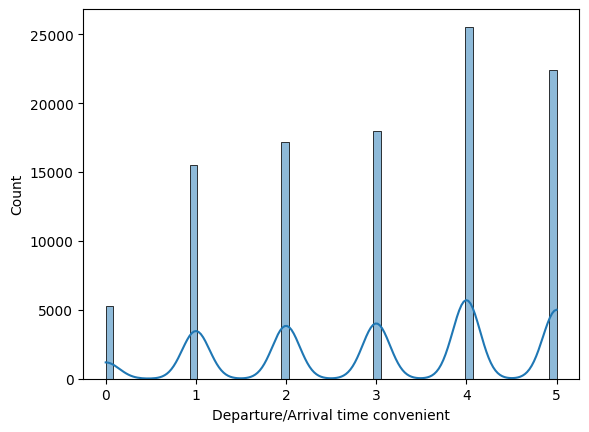

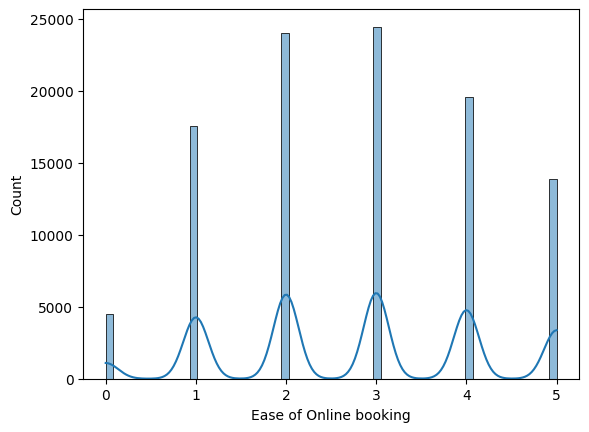

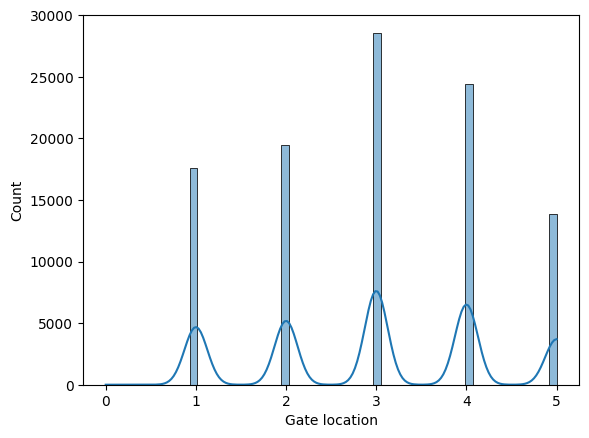

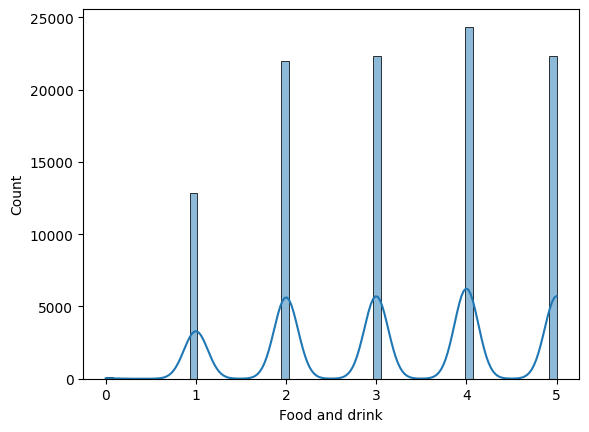

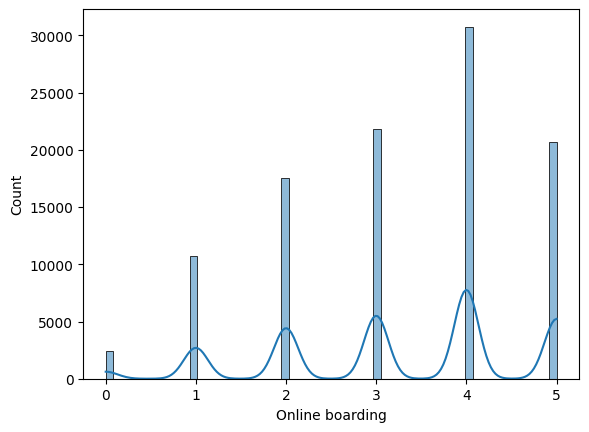

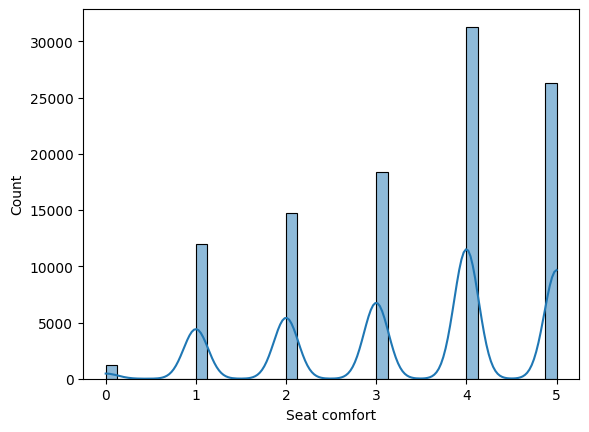

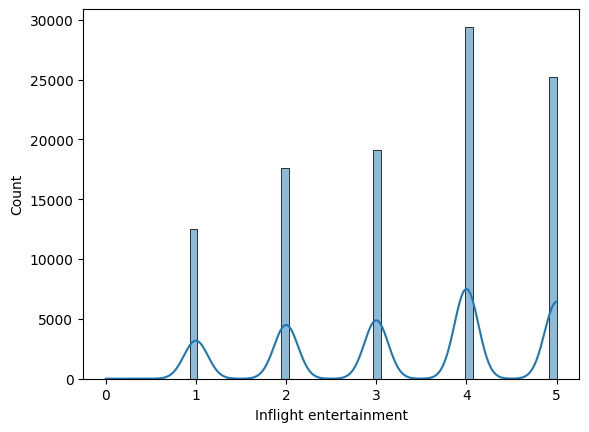

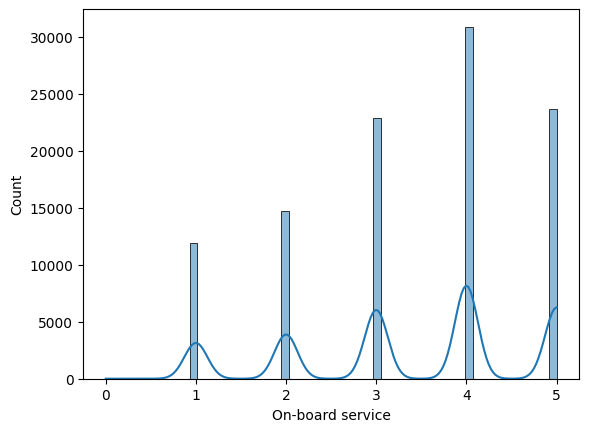

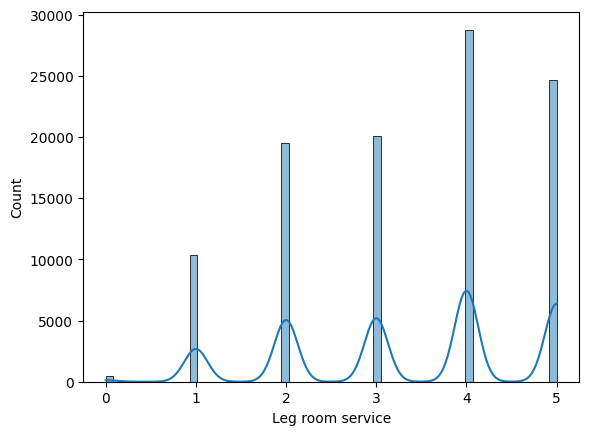

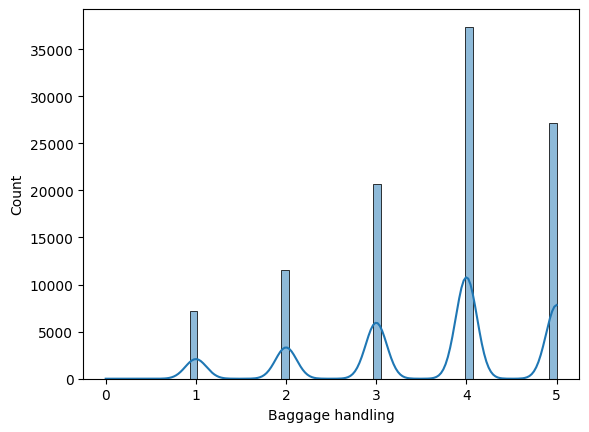

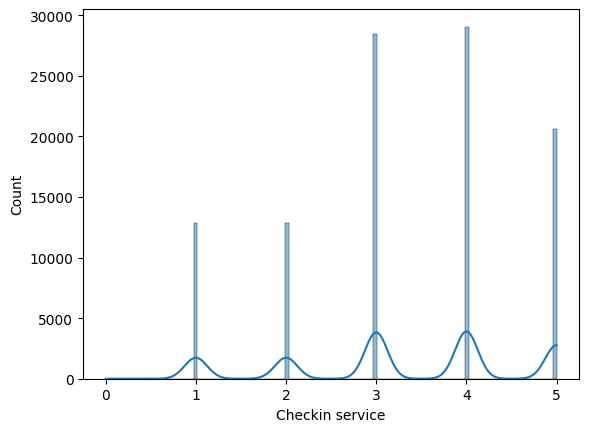

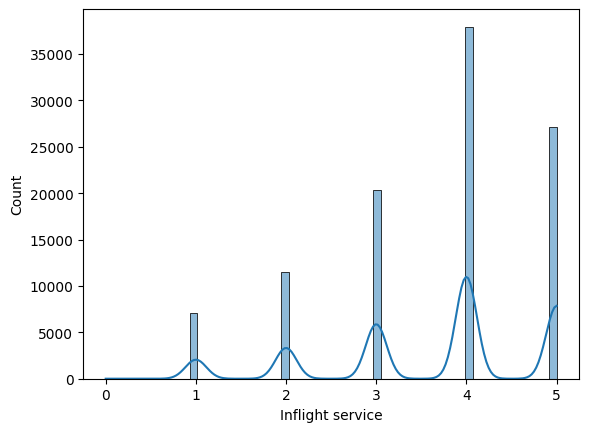

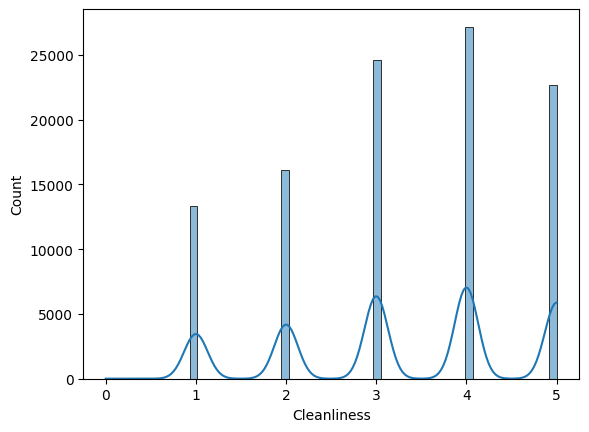

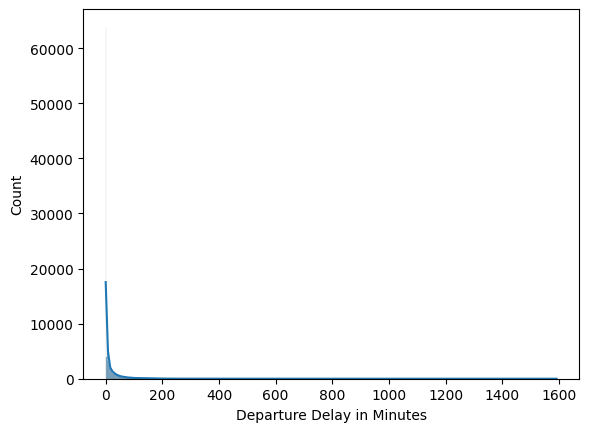

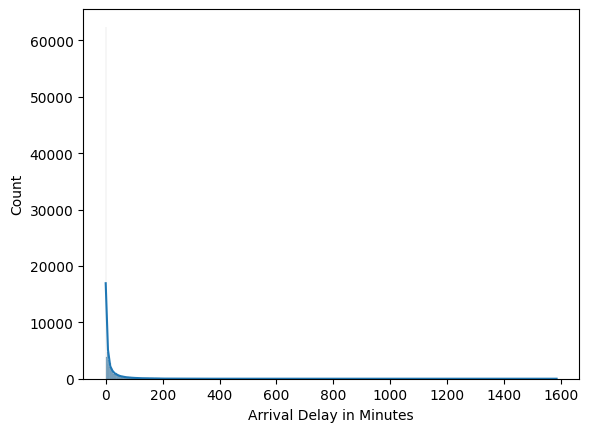

Feature vs Target


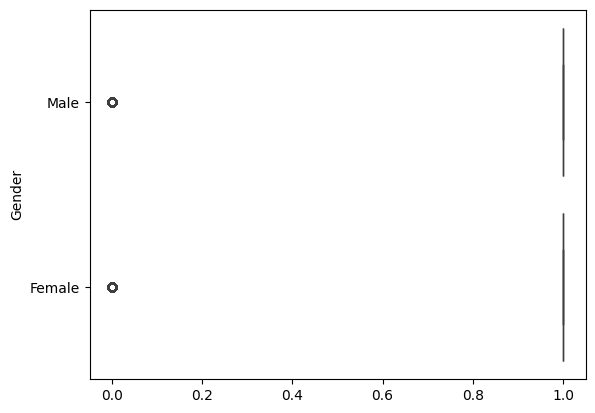

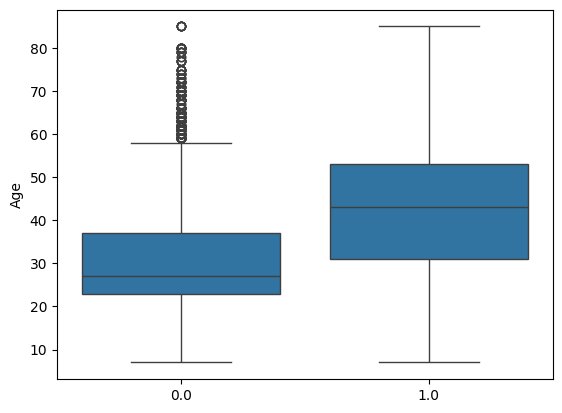

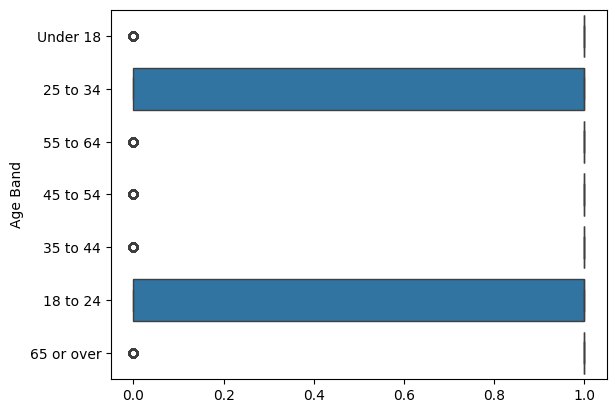

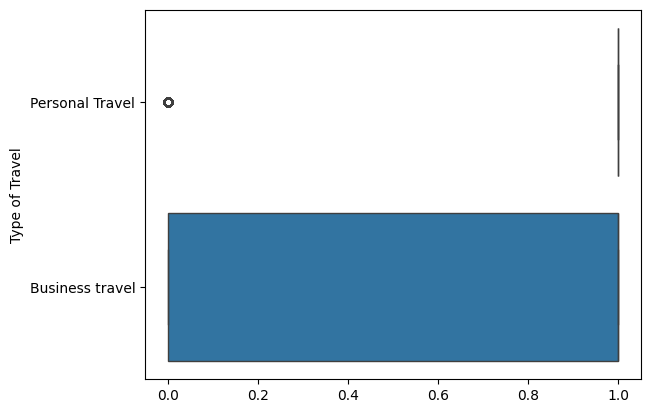

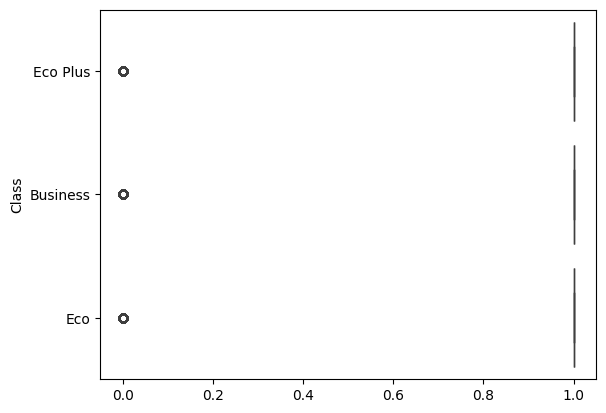

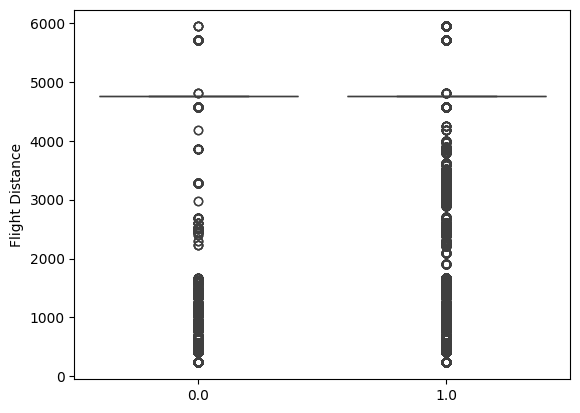

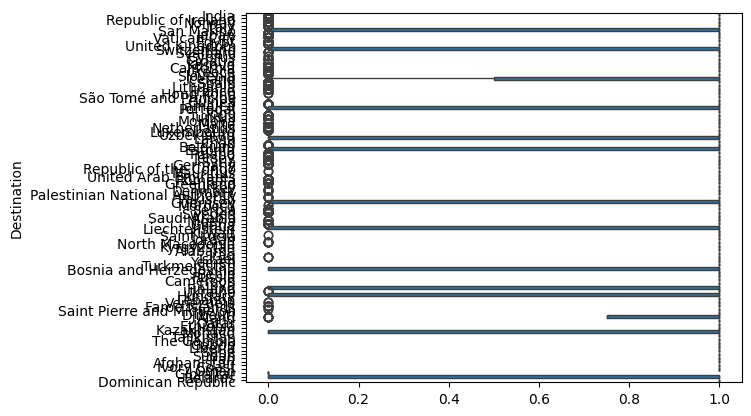

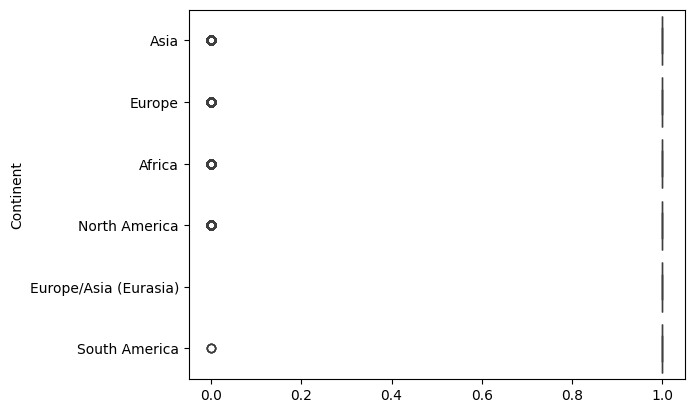

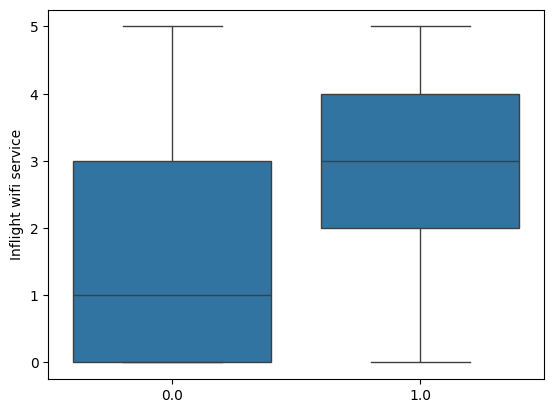

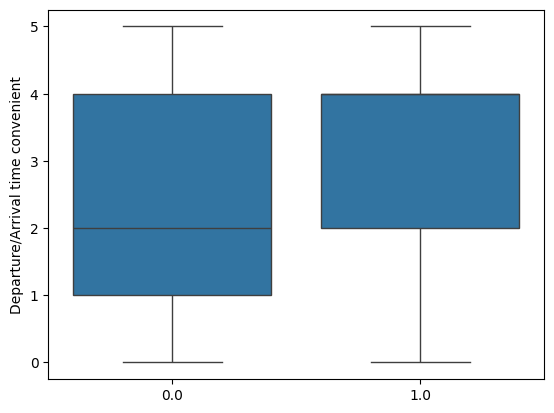

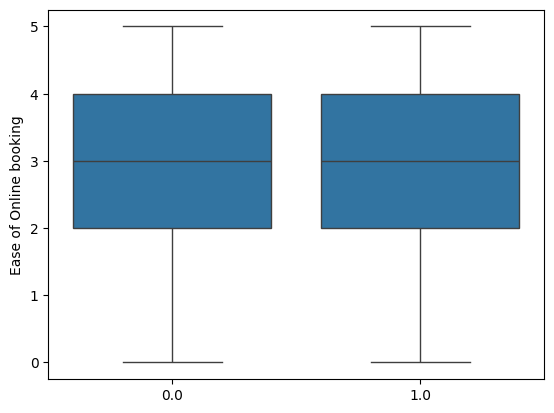

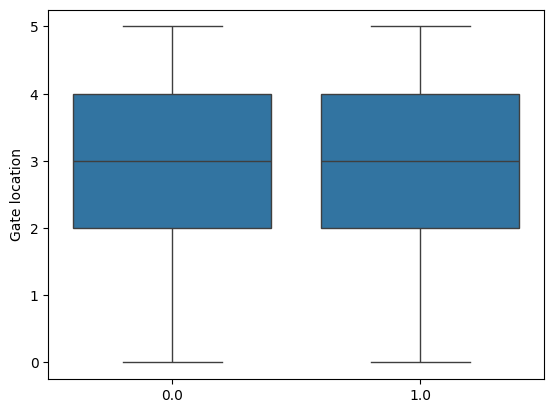

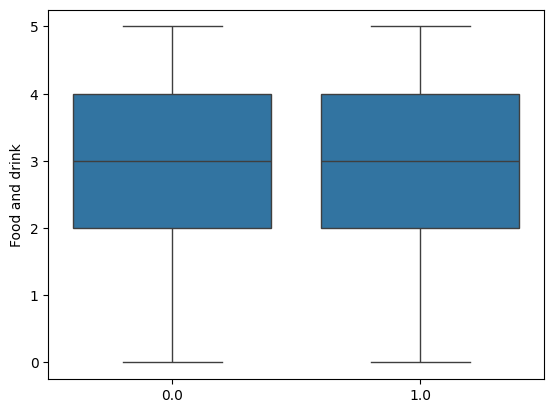

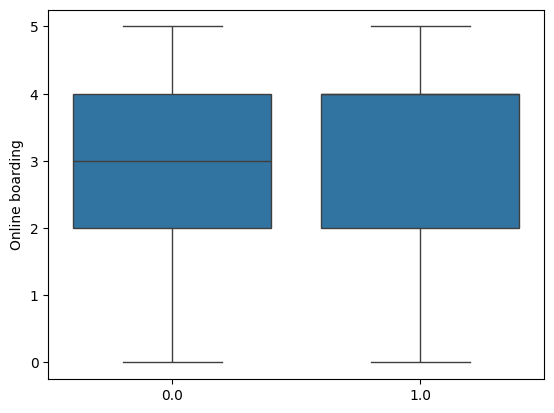

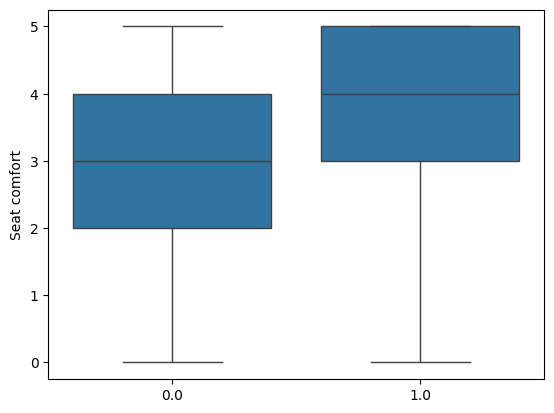

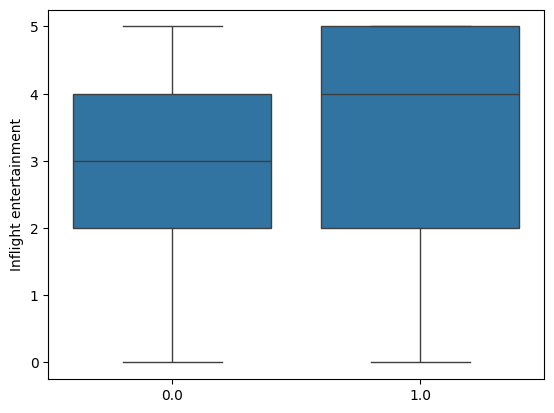

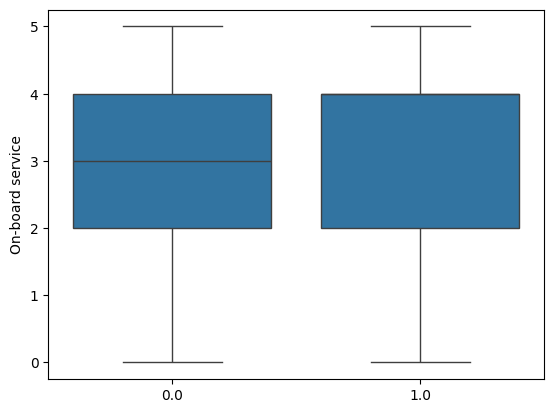

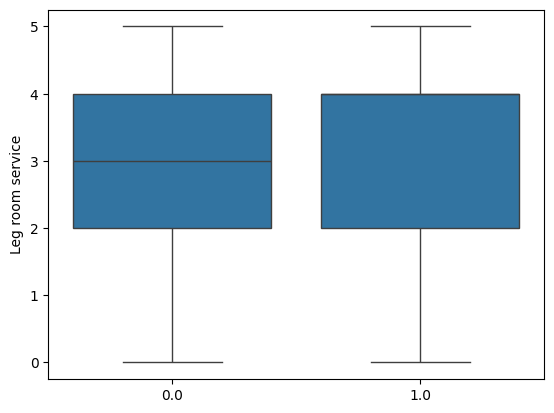

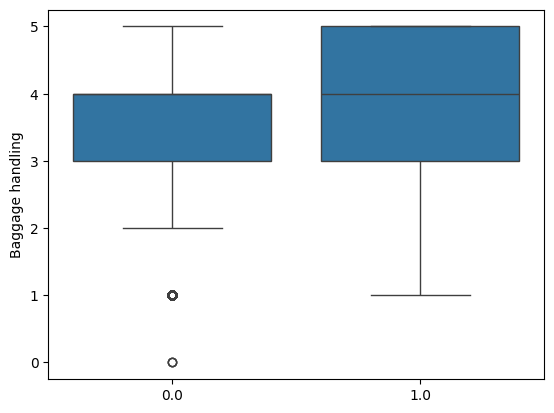

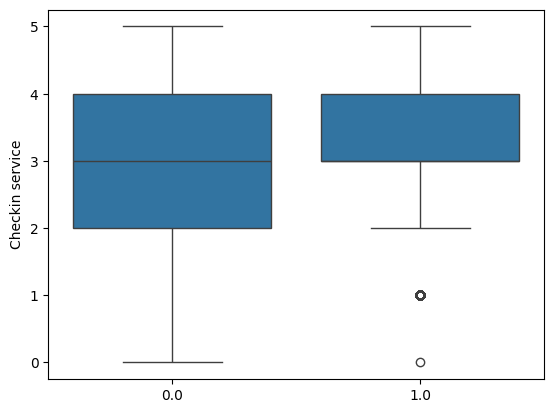

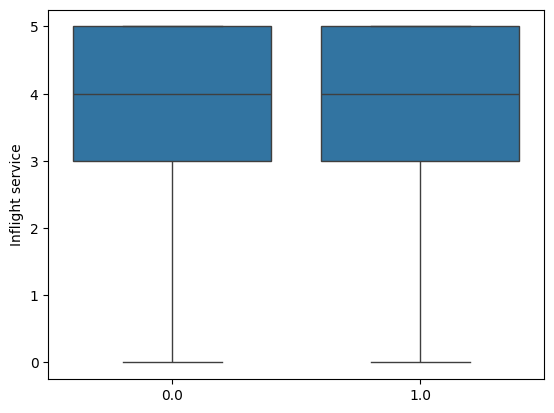

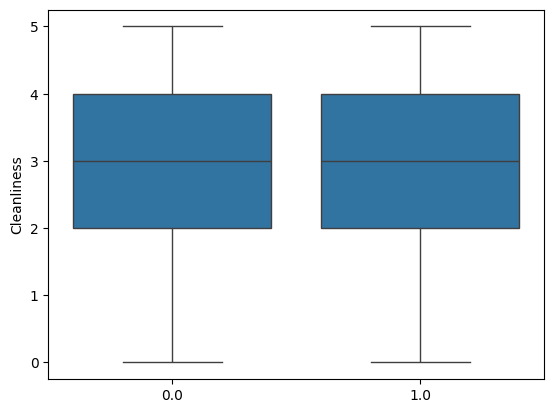

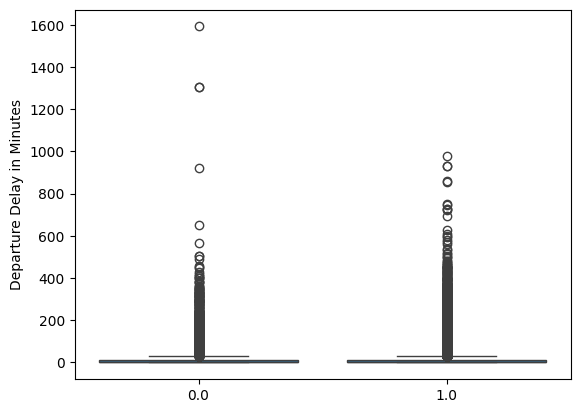

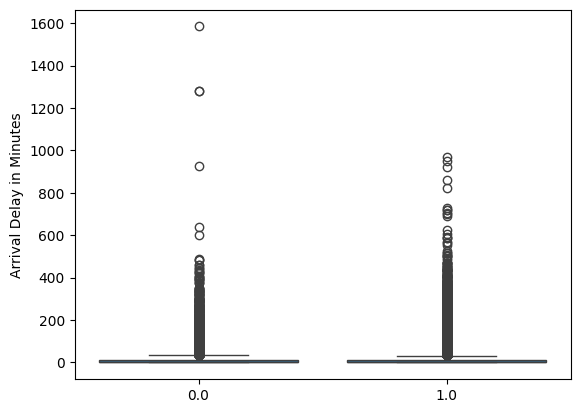

In [17]:
print(d.info())
print(d.describe())
print(d.isnull().sum())

import seaborn as sb
import matplotlib.pyplot as plt
sb.countplot(x = y, data = d)
plt.show()

for feature in features.columns:
    sb.histplot(features[feature], kde = True)
    plt.show()

print ("Feature vs Target")
for feature in features.columns:
    sb.boxplot(x = y, y = features[feature])
    plt.show()

Analytical Model 1: Logistic Regression

In [23]:
import math
rows = x_train.shape[0]
columns = x_train.shape[1]
w = np.random.normal(0, 0.01, size=columns)
b = 0.0
def logistic_hyp(w,b,x,size):
    z = b
    for i in range (0, size):
        z = z + w[i]*x[i]
    g = 1/(1 + np.exp(-(z)))
    return g

hyp_l = np.zeros(rows)
for i in range(0, rows):
    hyp_l[i] = logistic_hyp(w,b,x_train[i],columns)

def cost(hyp, y, size):
    loss = np.zeros(size);
    for i in range(0, size):
        loss[i] = -y[i]*np.log(hyp[i]) - (1-y[i])*np.log(1-hyp[i])
    sum_loss = 0
    for i in range(0, size):
        sum_loss = sum_loss + loss[i]
    j = (1/size)*sum_loss
    return j

cost_l = cost(hyp_l, y_train, rows)

In [24]:
def gradient_descent(X,Y,H,alpha,W,B,rows,cols):
    error = H-Y
    dw = (1/rows) * np.dot(X.T,error)
    db = (1/rows) * np.sum(error)
    W -= alpha * dw
    B -= alpha * db
    return (W,B)

w_updated = w
b_updated = b
alpha = 0.1
total_epochs = 150
w_arr = np.zeros((total_epochs, columns), dtype=float)
b_arr = np.zeros(total_epochs)
cost_arr = np.zeros(2 * total_epochs)
for a in range(0, total_epochs, 1):
    (w_updated, b_updated) = gradient_descent(x_train, y_train, hyp_l, alpha, w_updated, b_updated, rows, columns)
    w_arr[a] = w_updated
    b_arr[a] = b_updated
    for i in range(0, rows):
        hyp_l[i] = logistic_hyp(w_updated, b_updated ,x_train[i], columns)
    cost_l = cost(hyp_l, y_train, rows)
    cost_arr[a] = cost_l
    print("Epoch No.", a+1, "cost", cost_l)

Epoch No. 1 cost 0.6781498807065369
Epoch No. 2 cost 0.6619693598610803
Epoch No. 3 cost 0.6468520822684024
Epoch No. 4 cost 0.6326984297057101
Epoch No. 5 cost 0.619419965684123
Epoch No. 6 cost 0.6069382085316991
Epoch No. 7 cost 0.5951834726313125
Epoch No. 8 cost 0.5840938056588313
Epoch No. 9 cost 0.57361403340514
Epoch No. 10 cost 0.5636949133495502
Epoch No. 11 cost 0.5542923919485615
Epoch No. 12 cost 0.5453669572846852
Epoch No. 13 cost 0.5368830772863976
Epoch No. 14 cost 0.5288087134658904
Epoch No. 15 cost 0.5211149005387963
Epoch No. 16 cost 0.5137753830658296
Epoch No. 17 cost 0.5067663011861082
Epoch No. 18 cost 0.5000659184730074
Epoch No. 19 cost 0.49365438586412347
Epoch No. 20 cost 0.4875135364614434
Epoch No. 21 cost 0.481626706751514
Epoch No. 22 cost 0.4759785804539435
Epoch No. 23 cost 0.47055505177606355
Epoch No. 24 cost 0.4653431053384014
Epoch No. 25 cost 0.4603307104500138
Epoch No. 26 cost 0.45550672776323736
Epoch No. 27 cost 0.45086082663378124
Epoch No. 

In [25]:
alpha2 = 0.1
for a in range(0, total_epochs, 1):
    (w_updated, b_updated) = gradient_descent(x_train, y_train, hyp_l, alpha2, w_updated, b_updated, rows, columns)
    w_arr[a] = w_updated
    b_arr[a] = b_updated
    for i in range(0, rows):
        hyp_l[i] = logistic_hyp(w_updated, b_updated ,x_train[i], columns)
    cost_l = cost(hyp_l, y_train, rows)
    cost_arr[a + 150] = cost_l
    print("Epoch No.", a+1, "cost", cost_l)

Epoch No. 1 cost 0.27655094028905014
Epoch No. 2 cost 0.2760918562111837
Epoch No. 3 cost 0.2756373661350223
Epoch No. 4 cost 0.2751873979333661
Epoch No. 5 cost 0.2747418810624104
Epoch No. 6 cost 0.2743007465172062
Epoch No. 7 cost 0.27386392678847493
Epoch No. 8 cost 0.27343135582104267
Epoch No. 9 cost 0.2730029689735455
Epoch No. 10 cost 0.272578702979582
Epoch No. 11 cost 0.2721584959100653
Epoch No. 12 cost 0.2717422871369089
Epoch No. 13 cost 0.27133001729781153
Epoch No. 14 cost 0.2709216282623013
Epoch No. 15 cost 0.2705170630987819
Epoch No. 16 cost 0.27011626604274247
Epoch No. 17 cost 0.2697191824658819
Epoch No. 18 cost 0.269325758846321
Epoch No. 19 cost 0.26893594273970667
Epoch No. 20 cost 0.2685496827512638
Epoch No. 21 cost 0.2681669285087003
Epoch No. 22 cost 0.2677876306359543
Epoch No. 23 cost 0.2674117407278085
Epoch No. 24 cost 0.2670392113252555
Epoch No. 25 cost 0.2666699958916093
Epoch No. 26 cost 0.26630404878938935
Epoch No. 27 cost 0.2659413252578841
Epoch

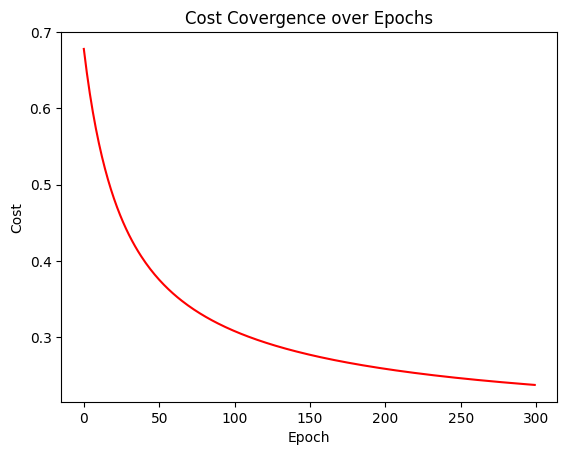

In [26]:
epochs = np.arange(0, 300)
plt.plot(epochs, cost_arr, color='red', label='Training Cost')
plt.title('Cost Covergence over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.show()

In [27]:
rows_val = x_val.shape[0]
columns_val = x_val.shape[1]

hyp_val = np.zeros(rows_val)

for i in range (0, rows_val):
  hyp_val[i] = logistic_hyp(w_updated, b_updated, x_val[i], columns_val)

val_out = np.zeros(rows_val)
counter = 0
for hyp in hyp_val:
  if (hyp >= 0.5):
    val_out[counter] = 1
  elif (hyp < 0.5):
    val_out[counter] = 0
  else:
    raise Exception("Invalid hypothesis value")
  counter += 1

val_accuracy = np.mean(val_out.flatten() == y_val.flatten())
val_cost = cost(hyp_val, y_val, columns_val)

print("Training cost:", cost_l)
print("Validation cost:", val_cost)
print("Validation accuracy:", val_accuracy)

Training cost: 0.23703896629448404
Validation cost: 0.21645612652267107
Validation accuracy: 0.9104908565928778


In [28]:
np.save('trained_logistic_weights.npy', w_updated)
np.save('trained_logistic_bias.npy', b_updated)

true_positive_val_logistic = np.sum((val_out==1) & (y_val.flatten()==1))
true_negative_val_logistic = np.sum((val_out==0) & (y_val.flatten()==0))
false_positive_val_logistic = np.sum((val_out==1) & (y_val.flatten()==0))
false_negative_val_logistic = np.sum((val_out==0) & (y_val.flatten()==1))
print("Correctly classified:", true_positive_val_logistic + true_negative_val_logistic)
print("Misclassified:", false_positive_val_logistic + false_negative_val_logistic)

Correctly classified: 9460
Misclassified: 930


In [10]:
def logistic_regression(x):
  rows = x.shape[0]
  columns = x.shape[1]
  hyp = np.zeros(rows)
  for i in range(0, rows):
    hyp[i] = logistic_hyp(w_updated, b_updated, x[i], columns)
  output = np.zeros(rows)
  counter = 0
  for h in hyp:
    if (h >= 0.5):
      output[counter] = 1
    elif (h < 0.5):
      output[counter] = 0
    else:
      raise Exception("Invalid hypothesis value")
    counter += 1
  return output

Analytical Model 2: Decision Tree

In [11]:
class Node:
  def __init__(self, Depth):
    self.feature = None
    self.split_value = None
    self.left = None
    self.right = None
    self.label = None
    self.is_leaf = False
    self.depth = Depth

class Tree:
  def __init__(self, depth):
    self.root = None
    self.max_depth = depth

  def entropy(self, y, y0 = None, y1 = None):
    if y0 is None:
      y0 = y[y==0]
    if y1 is None:
      y1 = y[y==1]
    length = len(y)
    if length == 0:
      return 0
    l1 = np.sum(y1) if y1 is not None else 0
    l0 = length - l1
    p0 = l0 / length
    p1 = l1 / length
    h = 0
    for p in [p0,p1]:
      if p > 0:
        h -= p * np.log2(p)
    return h

  def build(self, x, y, depth):
    node = Node(depth)
    if (self.root == None):
      self.root = node
    x0 = x[y==0]
    x1 = x[y==1]
    y0 = y[y==0]
    y1 = y[y==1]
    if len(y0) == 0 or len(y1) == 0 or depth >= self.max_depth or len(y) < 20:
      node.label = 1 if len(y1) >= len(y0) else 0
      node.is_leaf = True
      return node
    node.impurity = self.entropy(y,y0,y1)

    best_gain = 0
    best_feature = None
    threshold = None

    for f in range(0, x.shape[1]):
      values = np.unique(np.nanpercentile(x[:, f], np.linspace(0, 100, 50)))
      for thresh in values:
        left = x[:,f] < thresh
        right = x[:,f] >= thresh
        if sum(left) == 0 or sum(right) == 0:
          continue
        y_left = y[left]
        y_right = y[right]
        impurity_split = (len(y_left)/len(y)) * self.entropy(y_left) + (len(y_right)/len(y)) * self.entropy(y_right)
        gain = node.impurity - impurity_split
        if gain > best_gain:
          best_gain = gain
          best_feature = f
          threshold = thresh

    if best_gain <= 0:
      node.is_leaf = True
      node.label = 1 if len(y1) >= len(y0) else 0
      return node
    node.feature = best_feature
    node.split_value = threshold
    left = x[:,best_feature] < threshold
    right = x[:,best_feature] >= threshold

    node.left = self.build(x[left], y[left], depth + 1)
    node.right = self.build(x[right], y[right], depth + 1)
    return node

  def fit(self, x, y, depth):
    y_flat = y.ravel()
    self.root = self.build(x, y_flat, depth)

  def predict(self, x, node):
    if node.is_leaf:
      return node.label
    if x[node.feature] < node.split_value:
      return self.predict(x, node.left)
    else:
      return self.predict(x, node.right)

  def prediction(self, x):
    size = len(x)
    prediction_arr = np.zeros(size)
    for i in range(0, size):
      label = self.predict(x[i], self.root)
      prediction_arr[i] = label
    return prediction_arr


In [12]:
train_dt = Tree(30)
train_dt.build(x_train, y_train,0)

In [13]:
left_child = train_dt.root.left
right_child = train_dt.root.right

print("Root Split: Feature", train_dt.root.feature, "at value", train_dt.root.split_value)
if left_child and not left_child.is_leaf:
    print("Left Child Split: Feature", left_child.feature)

if right_child:
    print("Right Child is_leaf:", right_child.is_leaf)
    if not right_child.is_leaf:
        print("Right Child Split: Feature", right_child.feature, "at value", right_child.split_value)
    else:
        print("Right Child is a Leaf predicting:", right_child.label)

parent_entropy = train_dt.root.impurity
left_entropy = train_dt.root.left.impurity
right_entropy = train_dt.root.right.impurity

print("Root Entropy:", parent_entropy)
print("Left Child Entropy:", left_entropy)
print("Right Child Entropy:", right_entropy)

def get_leaf_count(node):
    if node.is_leaf:
        return 1
    return get_leaf_count(node.left) + get_leaf_count(node.right)

print("Total Leaves:",get_leaf_count(train_dt.root))

y_predict = train_dt.prediction(x_val)
accuracy_dt = np.mean(y_predict == y_val)
print ("Validation Accuracy:", accuracy_dt)

Root Split: Feature 2 at value -1.0514401426831066
Left Child Split: Feature 4
Right Child is_leaf: False
Right Child Split: Feature 26 at value 1.1057952728093112
Root Entropy: 0.6835873218405597
Left Child Entropy: 0.7991797330343215
Right Child Entropy: 0.5308797254908681
Total Leaves: 724
Validation Accuracy: 0.9851780558229066


Testing Phase

In [14]:
import sklearn.metrics as sm
prediction_lr = logistic_regression(x_test)
accuracy_lr = sm.accuracy_score(y_test, prediction_lr)
prediction_dt = train_dt.prediction(x_test)
accuracy_dt = sm.accuracy_score(y_test, prediction_dt)

print("Logistic Regression Accuracy:", accuracy_lr)
print("Decision Tree Accuracy:", accuracy_dt)

Logistic Regression Accuracy: 0.9135790588008854
Decision Tree Accuracy: 0.9844095852179771


In [15]:
hyp_test = np.zeros(x_test.shape[0])
for i in range(0, x_test.shape[0]):
  hyp_test[i] = logistic_hyp(w_updated, b_updated, x_test[i], x_test.shape[1])
cost_test = cost(hyp_test, y_test, x_test.shape[0])
print("Logistic Regression Cost (Binary Cross Entropy Loss)", cost_test)

test_entropy_i = train_dt.entropy(y_test)
test_entropy_f = train_dt.entropy(y_test[prediction_dt == y_test])
gain = test_entropy_i - test_entropy_f
print("Decision Tree, Initial Test Entropy", test_entropy_i)
print("Decision Tree, Final Test Entropy", test_entropy_f)
print("Decision Tree, Information Gain", gain)

Logistic Regression Cost (Binary Cross Entropy Loss) 0.2431589620784243
Decision Tree, Initial Test Entropy 0.6932894144191049
Decision Tree, Final Test Entropy 0.6774566262110161
Decision Tree, Information Gain 0.015832788208088755


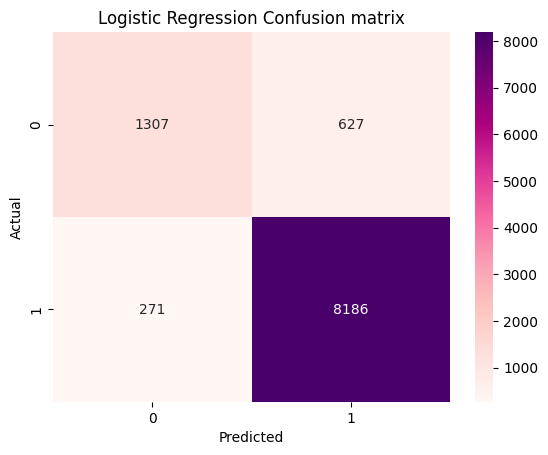

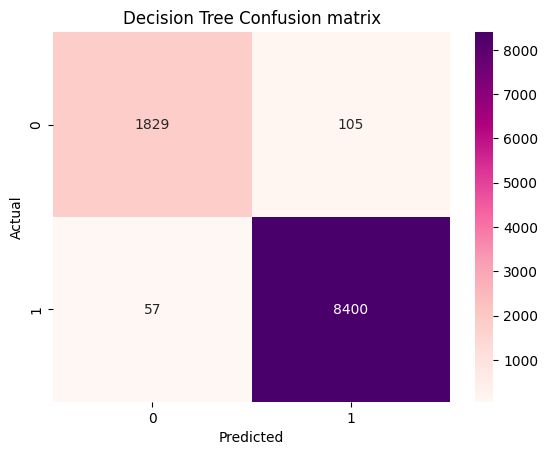

In [18]:
c_lr = sm.confusion_matrix(y_test, prediction_lr)
c_dt = sm.confusion_matrix(y_test, prediction_dt)

sb.heatmap(c_lr, annot= True, fmt= 'd', cmap= 'RdPu')
plt.title("Logistic Regression Confusion matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

sb.heatmap(c_dt, annot= True, fmt= 'd', cmap= 'RdPu')
plt.title("Decision Tree Confusion matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [19]:
print("Decision Tree Classification Report:")
dt_report = sm.classification_report(y_test, prediction_dt)
print(dt_report, end="\n")
print("Logistic Regression Classification Report:")
lr_report = sm.classification_report(y_test, prediction_lr)
print(lr_report)

Decision Tree Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96      1934
         1.0       0.99      0.99      0.99      8457

    accuracy                           0.98     10391
   macro avg       0.98      0.97      0.97     10391
weighted avg       0.98      0.98      0.98     10391

Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.68      0.74      1934
         1.0       0.93      0.97      0.95      8457

    accuracy                           0.91     10391
   macro avg       0.88      0.82      0.85     10391
weighted avg       0.91      0.91      0.91     10391

